# FEM Convergence analysis for Darcy

In [10]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]  # if notebook is in configs/notebooks/
sys.path.insert(0, str(PROJECT_ROOT))

import os
from tqdm import tqdm
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from fenics import *


from permeability.lognormalField import LognormalField
from permeability.multiphase import MultiphaseField


from fem.darcyProblem import Darcy


def analyticLognormal(dim, corrLength, mu, sigma, numberOfPhases, phaseValues, seed):
    """
    Returns an analytic smooth lognormal permeability field.
    """

    field = LognormalField(
        dim=dim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
    )

    xi = field.sampleXi(seed=seed, distribution="uniform")

    field.setXi(xi)

    return field


def analyticMultiphase(dim, corrLength, mu, sigma, numberOfPhases, phaseValues, seed):
    """
    Returns an analytic multiphase permeability field.
    """

    field = MultiphaseField(
        dim=dim,
        numberOfPhases=numberOfPhases,
        phaseValues=phaseValues,
        phaseBoundaries=None,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
    )

    xi = field.sampleXi(seed=seed, distribution="uniform")

    field.setXi(xi)

    return field

In [2]:
import matplotlib.pyplot as plt

font_size=12
title_size=14
label_size=13
tick_size=11
legend_size=10
dpi=300


plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

## Reference solution test
To serve as a benchmark, we test the numerical implementation for the problem on a manufactured problem. 
For this, suppose $\kappa(x,y) = 1$ and we have a generic pressure given as 
\begin{equation*}
    p(x,y) = y + A \cos(\pi x) \sin(\pi y).
\end{equation*}
This choice is particulary nice since we have 
\begin{equation*}
    p(x,0) = 0, \quad p(x,1) = 1 
\end{equation*}
and the solution is analytic. The corresponding flux is 
\begin{equation*}
    q(x,y) = -\nabla p(x,y) = 
    -\begin{pmatrix}
        \dfrac{\partial p}{\partial x} \\
        \dfrac{\partial p}{\partial y}
    \end{pmatrix}
    =
    \begin{pmatrix}
        A\pi \sin(\pi x)\sin(\pi y) \\
        -1 - A\pi \cos(\pi x)\cos(\pi y)
    \end{pmatrix}.
\end{equation*}
We can now calculate the right-hand-side of our PDE $- \nabla \cdot (\kappa \nabla p) = - \Delta p = f$. Computing the derrivatives yields
\begin{align*}
    \frac{\partial p}{\partial x} &= -A \pi \sin(\pi x)\sin(\pi y),\\
    \frac{\partial^2 p}{\partial x^2} &= -A \pi^2 \cos(\pi x)\sin(\pi y),
\end{align*}

\begin{align*}
    \frac{\partial p}{\partial y} &= 1 + A\pi \cos(\pi x)\cos(\pi y), \\
    \frac{\partial^2 p}{\partial y^2} &= -A\pi^2 \cos(\pi x)\sin(\pi y).
\end{align*}

Thus the Laplacian becomes
\begin{equation*}
    \Delta p(x,y) = \frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = -2 A \pi^2 \cos(\pi x) \sin(\pi y) = -f(x,y).
\end{equation*}
And therefore
\begin{equation*}
    f(x,y) = - \Delta p(x,y) = 2 A \pi^2 \cos(\pi x) \sin(\pi y).
\end{equation*}

We can now compare the numerical solution agains the reference solution to establish the convergence order of our methods.


In [5]:
A = 0.1

pRef = Expression(
    "x[1] + A*cos(pi*x[0])*sin(pi*x[1])",
    degree=10,
    A=A,
    pi=np.pi,
)


qRef = Expression(
    (
        "A*pi*sin(pi*x[0])*sin(pi*x[1])",
        "-1.0 - A*pi*cos(pi*x[0])*cos(pi*x[1])",
    ),
    degree=10,
    A=A,
    pi=np.pi,
)

f = Expression(
    "2.0*A*pi*pi*cos(pi*x[0])*sin(pi*x[1])",
    degree=10,
    A=A,
    pi=np.pi,
)



degrees = [1, 2]
Ls = [2, 3, 4, 5, 6, 7]
elementTypes = ["CG", "RT"]

from types import SimpleNamespace
constant_permeability = SimpleNamespace(
    isDiscontinuous=False,
    setXi=lambda xi: None,  # Ignore stochastic input
    adaptToMesh=lambda mesh, elementType, degree: interpolate(
        Constant(1.0),
        FunctionSpace(mesh, elementType, degree),
    ),
)


rows = []

configs = list(product(elementTypes, degrees, Ls))

for elementType, degree, L in tqdm(configs, desc="Running Darcy convergence", total=len(configs)):

    solver = "mumps"
    precon = None


    # Darcy problem
    problem = Darcy(
        permeabilityField=constant_permeability,
        meshLevel=L,
        degree=degree,
        elementType=elementType,
        darcySolver=solver,
        darcyPrecon=precon,
        pTop=1.0,
        pBottom=0.0,
        f=f,
        plotSolution=False,
        femDarcyVerbose=False,
        linearSolverVerbose=False,
        estimateFemError=False,
        computeMore=False,
    )

    p_h, q_h, info = problem.solve()

    # Pressure errors
    p_L2_error = errornorm(pRef, p_h, norm_type="L2", degree_rise=3)

    # Flux errors
    q_L2_error = errornorm(qRef, q_h, norm_type="L2", degree_rise=3)
    q_Hdiv_error = errornorm(qRef, q_h, norm_type="Hdiv", degree_rise=3)

    rows.append(
        {
            "element_type": elementType,
            "degree": degree,
            "mesh_level": L,
            "h": problem.mesh.hmax(),
            "dofs": info["dofs"],
            "runtime": info["runtime"],
            "iterations": info["iterations"],
            "p_L2_error": p_L2_error,
            "q_L2_error": q_L2_error,
            "q_Hdiv_error": q_Hdiv_error
        }
    )


df = pd.DataFrame(rows)

df = df.sort_values(by=["element_type", "degree", "mesh_level"]).reset_index(drop=True)

#savePath = os.path.join("pklFiles", "darcyRefSolConvergence.pkl")
#df.to_pickle(savePath)
#print(f"\nSaved results to:\n{savePath}")


Running Darcy convergence: 100%|██████████| 24/24 [00:20<00:00,  1.16it/s]


In [6]:
#loadPath = os.path.join("pklFiles", "darcyRefSolConvergence.pkl")
#df = pd.read_pickle(loadPath)


def addConvergenceRates(df):
    """
    rate = log(e_i / e_{i+1}) / log(h_i / h_{i+1})
    """

    df = df.copy()

    error_cols = [col for col in df.columns if col.endswith("_error") ]

    rate_cols = [col.replace("_error", "_rate") for col in error_cols]

    for rate_col in rate_cols:
        df[rate_col] = np.nan

    grouped = df.groupby(["element_type", "degree"])

    for (element_type, degree), g in grouped:

        g = g.sort_values("mesh_level")

        idx = g.index
        h = g["h"].to_numpy()

        for err_col in error_cols:

            err = g[err_col].to_numpy()

            rate = np.full(len(err), np.nan)

            for i in range(1, len(err)):
                rate[i] = (np.log(err[i - 1] / err[i]) / np.log(h[i - 1] / h[i]) )

            rate_col = err_col.replace(
                "_error",
                "_rate",
            )

            df.loc[idx, rate_col] = rate

    return df

df = addConvergenceRates(df)

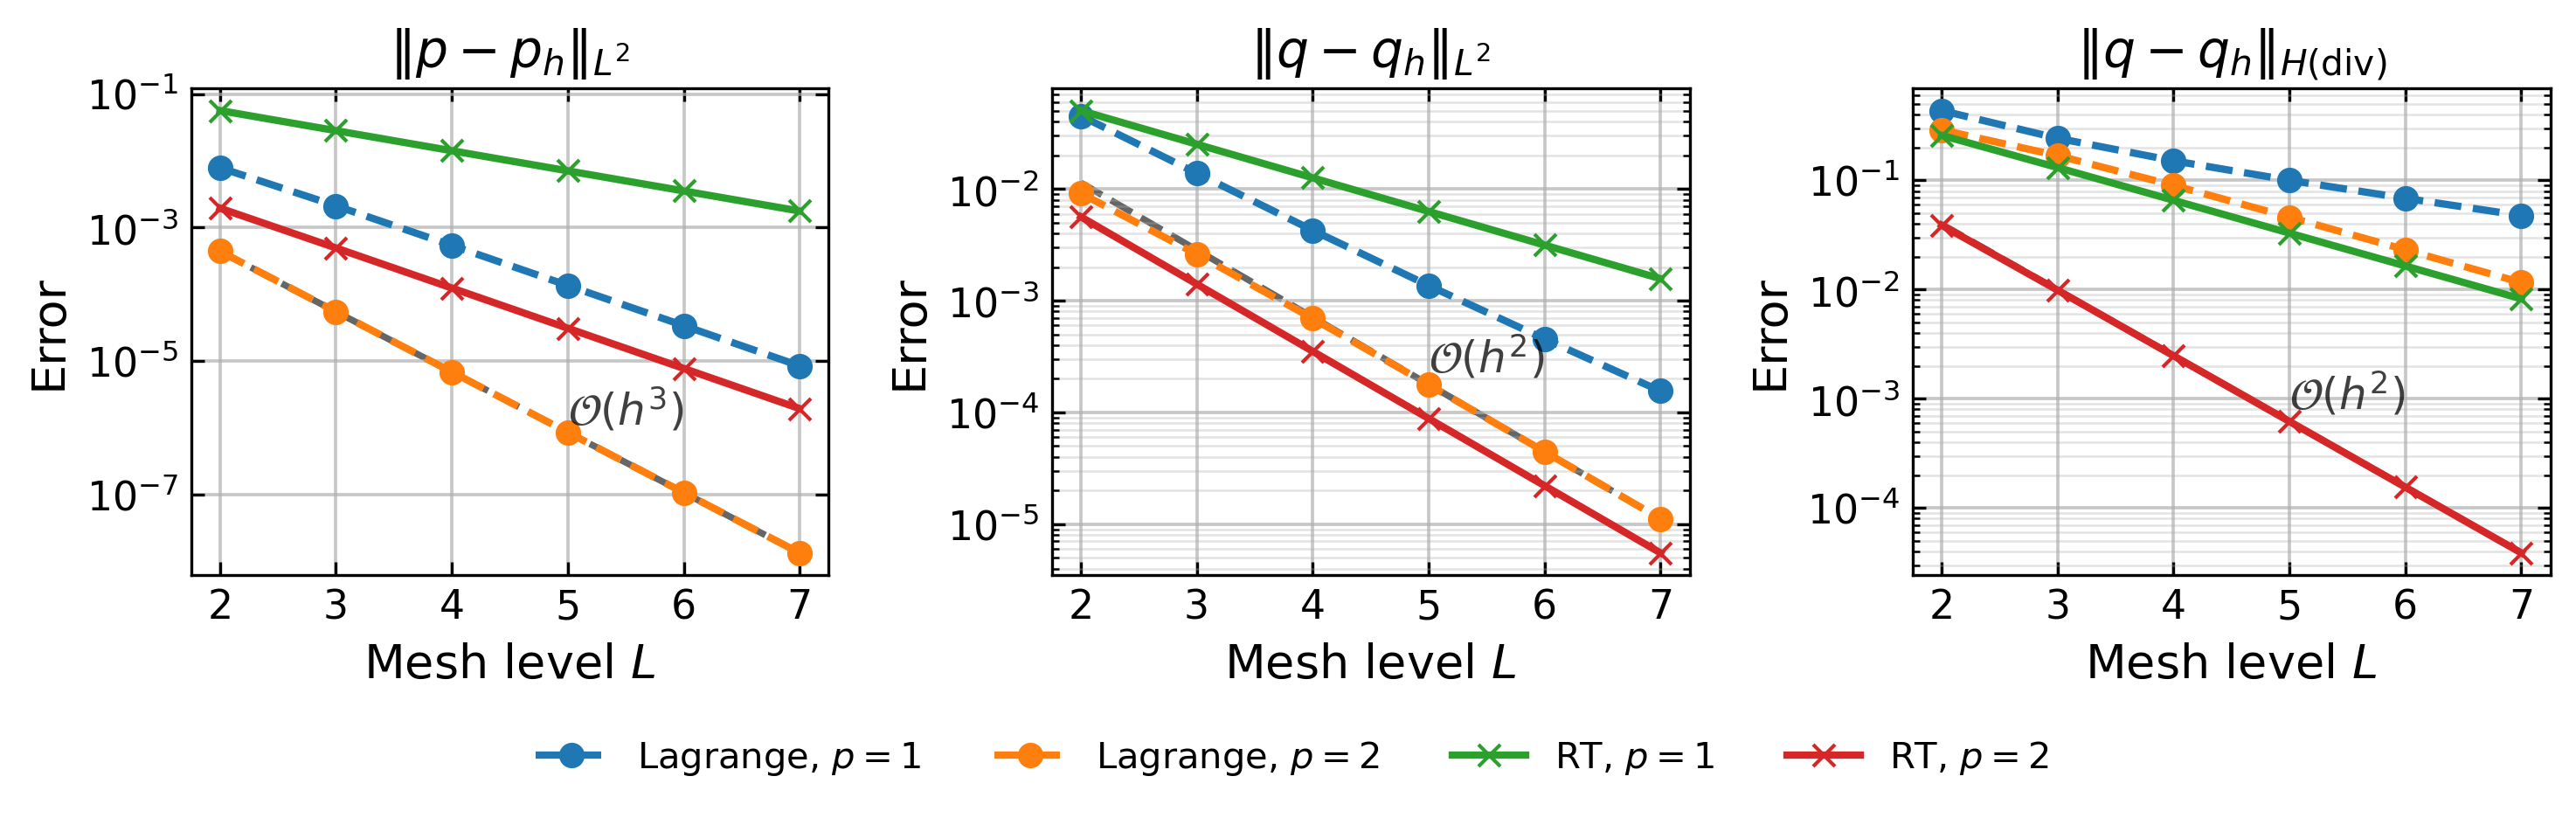

In [7]:
plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

error_cols = [
    "p_L2_error",
    "q_L2_error",
    "q_Hdiv_error",
]

error_labels = {
    "p_L2_error": r"$\|p-p_h\|_{L^2}$",
    "q_L2_error": r"$\|q-q_h\|_{L^2}$",
    "q_Hdiv_error": r"$\|q-q_h\|_{H(\mathrm{div})}$",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(10, 3.2),
    dpi=300,
    constrained_layout=False,
)

element_label = {
    "RT": "RT",
    "CG": "Lagrange",
    "DG": "Lagrange",
}

for ax, error_col in zip(axes, error_cols):

    for (element_type, degree), g in df.groupby(["element_type", "degree"]):

        label_name = element_label.get(element_type, element_type)
        marker = "x" if element_type == "RT" else "o"
        linestyle = "-" if element_type == "RT" else "--"

        g = g.sort_values("mesh_level")

        ax.semilogy(
            g["mesh_level"],
            g[error_col],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.0,
            markersize=6.0,
            label=rf"{label_name}, $p={degree}$",
        )

    if error_col == "q_Hdiv_error":
        ref_element = "RT"
        ref_degree = 2
    else:
        ref_element = "CG"
        ref_degree = 2

    g_ref = df[
        (df["element_type"] == ref_element)
        & (df["degree"] == ref_degree)
    ].sort_values("mesh_level")

    if not g_ref.empty and len(g_ref) >= 2:
        L_ref = g_ref["mesh_level"].to_numpy()
        h_ref = 2.0 ** (-L_ref)
        err_ref = g_ref[error_col].to_numpy()

        order = 3 if error_col == "p_L2_error" else 2

        h0 = h_ref[-2]
        e0 = err_ref[-2]

        ref_curve = e0 * (h_ref / h0) ** order

        ax.semilogy(
            L_ref,
            ref_curve,
            linestyle="--",
            linewidth=1.8,
            color="black",
            alpha=0.6,
            zorder=0,
        )

        mid = len(L_ref) // 2

        ax.text(
            L_ref[mid],
            ref_curve[mid] * 1.3,
            rf"$\mathcal{{O}}(h^{order})$",
            color="black",
            alpha=0.75,
        )

    ax.set_title(error_labels[error_col])
    ax.set_xlabel(r"Mesh level $L$")
    ax.set_ylabel("Error")

    ax.grid(True, which="major", linewidth=0.9, alpha=0.7)
    ax.grid(True, which="minor", linewidth=0.6, alpha=0.35)

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(which="both", direction="in", top=True, right=True)

handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.00),
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.86,
    bottom=0.28,
    wspace=0.35,
)

plt.show()

In [8]:
rate_cols = [
    col for col in df.columns
    if col.endswith("_rate")
]

table_rows = []

for (element_type, degree), g in df.groupby(
    ["element_type", "degree"]
):

    g = g.sort_values("mesh_level")

    row = {
        "Element": element_type,
        "Degree": degree,
    }

    for rate_col in rate_cols:

        # use finest mesh estimate
        val = g[rate_col].iloc[-1]

        norm_name = (
            rate_col
            .replace("_rate", "")
            .replace("_", " ")
        )

        row[norm_name] = val

    table_rows.append(row)

rate_table = pd.DataFrame(table_rows)

rate_table = rate_table.round(2)

rate_table

,Element,Degree,p L2,q L2,q Hdiv
0,CG,1,2.0,1.55,0.52
1,CG,2,3.0,2.00,1.00
2,RT,1,1.0,1.00,1.00
3,RT,2,2.0,2.00,2.00


## Linear solvers and preconditioning

In [11]:
dim = 15
corrLength = 0.001
mu = 1.0
sigma = 0.25
numberOfPhases = 2
phaseValues = [2, 8]

seeds = list(range(1, 21))
mesh_levels = [4, 5, 6]
degrees = [1, 2]

configs = [
    ("CG", "cg", "hypre"),
    ("CG", "cg", "ilu"),
    ("CG", "gmres", "ilu"),
    ("CG", "gmres", "hypre"),
    ("CG", "mumps", None),

    ("RT", "gmres", "ilu"),
    ("RT", "bcgs", "ilu"),
    ("RT", "bcgs", "bjacobi"), 
    ("RT", "bcgs", "sor"), 
    ("RT", "mumps", None),
]

fields = []

for seed in seeds:
    fields.append({
        "field_type": "lognormal",
        "seed": seed,
        "field": analyticLognormal(
            dim=dim,
            corrLength=corrLength,
            mu=mu,
            sigma=sigma,
            numberOfPhases=numberOfPhases,
            phaseValues=phaseValues,
            seed=seed,
        ),
    })

    fields.append({
        "field_type": "multiphase",
        "seed": seed,
        "field": analyticMultiphase(
            dim=dim,
            corrLength=corrLength,
            mu=mu,
            sigma=sigma,
            numberOfPhases=numberOfPhases,
            phaseValues=phaseValues,
            seed=seed,
        ),
    })

rows = []

benchmark_cases = list(
    product(configs, fields, mesh_levels, degrees)
)

for (elementType, solver, precon), field_info, mesh_level, degree in tqdm(
    benchmark_cases,
    total=len(benchmark_cases),
    desc="Solver/Preconditioner benchmark",
):

    field = field_info["field"]

    try:
        problem = Darcy(
            permeabilityField=field,
            meshLevel=mesh_level,
            degree=degree,
            elementType=elementType,
            darcySolver=solver,
            darcyPrecon=precon,
            relTol = 1e-9,
            absTol = 1e-11,
            maxIter = 10000,
            pTop=1.0,
            pBottom=0.0,
            plotSolution=False,
            femDarcyVerbose=False,
            linearSolverVerbose=False,
            estimateFemError=False,
            computeMore=False,
        )

        _, _, info = problem.solve()

        rows.append({
            "element_type": elementType,
            "solver": solver,
            "preconditioner": precon if precon is not None else "none",
            "field_type": field_info["field_type"],
            "seed": field_info["seed"],
            "mesh_level": mesh_level,
            "degree": degree,
            "converged": True,
            "runtime": info["runtime"],
            "iterations": info["iterations"],
            "error_message": None,
        })

    except Exception as e:
        rows.append({
            "element_type": elementType,
            "solver": solver,
            "preconditioner": precon if precon is not None else "none",
            "field_type": field_info["field_type"],
            "seed": field_info["seed"],
            "mesh_level": mesh_level,
            "degree": degree,
            "converged": False,
            "runtime": np.nan,
            "iterations": np.nan,
            "error_message": str(e),
        })



Solver/Preconditioner benchmark: 100%|██████████| 2400/2400 [10:38<00:00,  3.76it/s]


In [12]:
solver_order = ["cg", "gmres", "bcgs", "mumps"]
precon_order = ["hypre", "ilu", "bjacobi", "sor", "none"]
field_order = ["lognormal", "multiphase"]
element_order = ["CG", "RT"]

In [13]:
solver_runs = pd.DataFrame(rows)

solver_summary = (
    solver_runs
    .groupby([
        "element_type",
        "solver",
        "preconditioner",
        "field_type",
        "mesh_level",
        "degree",
    ])
    .agg(
        n_runs=("converged", "size"),
        n_failed=("converged", lambda x: (~x).sum()),
        mean_runtime=("runtime", "mean"),
        std_runtime=("runtime", "std"),
        mean_iterations=("iterations", "mean"),
        std_iterations=("iterations", "std"),
    )
    .reset_index()
)


solver_summary["element_type"] = pd.Categorical(
    solver_summary["element_type"],
    categories=element_order,
    ordered=True,
)
solver_summary["solver"] = pd.Categorical(
    solver_summary["solver"],
    categories=solver_order,
    ordered=True,
)
solver_summary["preconditioner"] = pd.Categorical(
    solver_summary["preconditioner"],
    categories=precon_order,
    ordered=True,
)
solver_summary["field_type"] = pd.Categorical(
    solver_summary["field_type"],
    categories=field_order,
    ordered=True,
)

solver_summary = (
    solver_summary
    .sort_values(
        by=[
            "element_type",
            "degree",
            "mesh_level",
            "solver",
            "preconditioner",
            "field_type",
        ]
    )
    .reset_index(drop=True)
)

os.makedirs("pklFiles", exist_ok=True)

runs_path = os.path.join("pklFiles", "darcySolverBenchmarkRuns_allLevels.pkl")
summary_path = os.path.join("pklFiles", "darcySolverBenchmarkSummary_allLevels.pkl")

#solver_runs.to_pickle(runs_path)
#solver_summary.to_pickle(summary_path)

#print(f"Saved runs to: {runs_path}")
#print(f"Saved summary to: {summary_path}")

solver_summary

,element_type,solver,preconditioner,field_type,mesh_level,degree,n_runs,n_failed,mean_runtime,std_runtime,mean_iterations,std_iterations
0,CG,cg,hypre,lognormal,4,1,20,0,0.001430,0.002867,6.550000,0.510418
1,CG,cg,hypre,multiphase,4,1,20,1,0.000905,0.000084,8.368421,2.033348
2,CG,cg,ilu,lognormal,4,1,20,0,0.000423,0.000030,30.400000,2.760625
3,CG,cg,ilu,multiphase,4,1,20,0,0.003377,0.007354,934.350000,2274.074972
4,CG,gmres,hypre,lognormal,4,1,20,0,0.000811,0.000085,5.350000,0.489360
...,...,...,...,...,...,...,...,...,...,...,...,...
115,RT,bcgs,bjacobi,multiphase,6,2,20,0,1.354429,0.147163,640.300000,68.736798
116,RT,bcgs,sor,lognormal,6,2,20,20,NaN,NaN,NaN,NaN
117,RT,bcgs,sor,multiphase,6,2,20,20,NaN,NaN,NaN,NaN
118,RT,mumps,none,lognormal,6,2,20,0,0.220517,0.052645,NaN,NaN


In [14]:
#loadPath = os.path.join("pklFiles", "darcySolverBenchmarkSummary_allLevels.pkl")
#solver_summary = pd.read_pickle(loadPath)
#solver_summary["mean_iterations"] = (solver_summary["mean_iterations"].round().astype("Int64"))

#loadPath = os.path.join("pklFiles", "darcySolverBenchmarkRuns_allLevels.pkl")
#solver_runs = pd.read_pickle(loadPath)


solver_summary_global = (
    solver_runs
    .groupby(
        [
            "element_type",
            "solver",
            "preconditioner",
            "field_type",
        ]
    )
    .agg(
        n_runs=("converged", "size"),
        n_failed=("converged", lambda x: (~x).sum()),
        mean_runtime=("runtime", "mean"),
        std_runtime=("runtime", "std"),
        mean_iterations=("iterations", "mean"),
        std_iterations=("iterations", "std"),
    )
    .reset_index()
)


solver_summary_global["element_type"] = pd.Categorical(
    solver_summary_global["element_type"],
    categories=element_order,
    ordered=True,
)

solver_summary_global["solver"] = pd.Categorical(
    solver_summary_global["solver"],
    categories=solver_order,
    ordered=True,
)

solver_summary_global["preconditioner"] = pd.Categorical(
    solver_summary_global["preconditioner"],
    categories=precon_order,
    ordered=True,
)

solver_summary_global["field_type"] = pd.Categorical(
    solver_summary_global["field_type"],
    categories=field_order,
    ordered=True,
)


solver_summary_global = (
    solver_summary_global
    .sort_values(
        by=[
            "element_type",
            "solver",
            "preconditioner",
            "field_type",
        ]
    )
    .reset_index(drop=True)
)


# Integer formatting
solver_summary_global["mean_iterations"] = (
    solver_summary_global["mean_iterations"]
    .round()
    .astype("Int64")
)

solver_summary_global["n_runs"] = (
    solver_summary_global["n_runs"]
    .astype(int)
)

solver_summary_global["n_failed"] = (
    solver_summary_global["n_failed"]
    .astype(int)
)

solver_summary_global


,element_type,solver,preconditioner,field_type,n_runs,n_failed,mean_runtime,std_runtime,mean_iterations,std_iterations
0,CG,cg,hypre,lognormal,120,0,0.006081,0.006808,7,0.488237
1,CG,cg,hypre,multiphase,120,11,0.007563,0.009123,9,2.454721
2,CG,cg,ilu,lognormal,120,6,0.216465,0.442558,1446,1962.289507
3,CG,cg,ilu,multiphase,120,50,0.054150,0.163769,912,1729.067762
4,CG,gmres,hypre,lognormal,120,0,0.005796,0.006451,6,0.357003
5,CG,gmres,hypre,multiphase,120,0,0.006827,0.007632,7,0.480429
6,CG,gmres,ilu,lognormal,120,0,0.042189,0.082869,191,236.020448
7,CG,gmres,ilu,multiphase,120,0,0.045279,0.086880,215,249.781193
8,CG,mumps,none,lognormal,120,0,0.059125,0.061450,<NA>,NaN
9,CG,mumps,none,multiphase,120,0,0.056476,0.046064,<NA>,NaN


### Self convergence 
We will beginn by assessing the discretization error of the FE approximation for lognormal and multiphase fields. 
Since we do not have a closed form solution, we will perform a self-convergence study using refined meshes.

##### Self convergence
Let $u$ denote the unknown exact solution and $u_h$ the FE approximation on a $h-$mesh. We expect the error to behave asymptotically as 
\begin{equation*}
    u_h = u + C h^p + \mathcal{O}(h^{p+1}),
\end{equation*}
where $C$ is an unknown constant, $p$ is the convergence order of the discretization and $h$ denotes the mesh size.

We compare solutions obtained on successive mesh refinements
\begin{equation*}
    u_h, \quad u_{h/2}, \quad u_{h/4}.
\end{equation*}
The darcy problem class has a function $\textit{estimateFemErrorByMeshRefinement()}$ that outputs the difference between FE solutions on two coonsecutive mesh levels:
\begin{equation*}
    e_h = \|u_{h/2} - I(u_h) \|_{L²},
\end{equation*}
where $I(u_h)$ denotes the interpolation (or projection) of the coarse solution onto the finer FE space.
We compute this for both the pressure field $p$ and the flux field $q$.
As the mesh is refined, these differences should decrease if the numerical solution converges.
Assuming asymptotic convergence, the differences satisfy
\begin{equation*}
    e_h \approx C h^p (1 - 2^{-p}),
\end{equation*}
which is obtained by subtracting the asymptotic error behavior from the beginning.
We can then estimate the observed convergence rate as 
\begin{equation*}
    p_{\text{obs}} = \frac{\log \left( e_h / e_{h/2} \right)}{ \log (2)},
\end{equation*}
which is obtained by taking the ration $e_h$ over $e_{h/2}$.

In [15]:
def make_field(field_type, seed):
    if field_type == "lognormal":
        return analyticLognormal(
            dim=dim,
            corrLength=corrLength,
            mu=mu,
            sigma=sigma,
            numberOfPhases=numberOfPhases,
            phaseValues=phaseValues,
            seed=seed,
        )

    if field_type == "multiphase":
        return analyticMultiphase(
            dim=dim,
            corrLength=corrLength,
            mu=mu,
            sigma=sigma,
            numberOfPhases=numberOfPhases,
            phaseValues=phaseValues,
            seed=seed,
        )



def solve_darcy(field, mesh_level, degree, element_type):
    
    solver = "mumps"
    precon = None

    problem = Darcy(
        permeabilityField=field,
        meshLevel=mesh_level,
        degree=degree,
        elementType=element_type,
        darcySolver=solver,
        darcyPrecon=precon,
        relTol = 1e-10,
        absTol = 1e-13,
        maxIter = 20000,
        pTop=1.0,
        pBottom=0.0,
        f=Constant(0.0),
        plotSolution=False,
        femDarcyVerbose=False,
        linearSolverVerbose=False,
        estimateFemError=False,
        computeMore=True # For mass error
    )

    p_h, q_h, info = problem.solve()

    return problem, p_h, q_h, info


In [4]:
# Field
dim = 15
corrLength = 0.001
mu = 1.0
sigma = 0.25
numberOfPhases = 2
phaseValues = [2, 8]

seeds = list(range(1, 11))

# FEM
elementTypes = ["CG", "RT"]
degrees = [1, 2]
mesh_levels = [2, 3, 4, 5, 6]
field_types = ["lognormal", "multiphase"]

rows = []



# Loop over settings
configs = list(product(field_types, seeds, elementTypes, degrees, mesh_levels))

for field_type, seed, element_type, degree, L in tqdm(configs, total=len(configs), desc="Darcy refinement errors"):

    field = make_field(field_type, seed)

    coarse, p_c, q_c, info_c = solve_darcy(
        field=field,
        mesh_level=L,
        degree=degree,
        element_type=element_type,
    )

    fine, p_f, q_f, info_f = solve_darcy(
        field=field,
        mesh_level=L + 1,
        degree=degree,
        element_type=element_type,
    )

    # Transfer coarse solution to fine spaces
    p_c_on_fine = interpolate(p_c, fine.Vp)

    if element_type == "CG":
        q_c_on_fine = project(q_c, fine.Vq)
    else:
        q_c_on_fine = interpolate(q_c, fine.Vq)

    # Refinement differences
    p_L2_error = errornorm(
        p_f,
        p_c_on_fine,
        norm_type="L2",
        degree_rise=3,
    )

    q_L2_error = errornorm(
        q_f,
        q_c_on_fine,
        norm_type="L2",
        degree_rise=3,
    )

    q_Hdiv_error = errornorm(
        q_f,
        q_c_on_fine,
        norm_type="Hdiv",
        degree_rise=3,
    )

    rows.append(
        {
            "field_type": field_type,
            "seed": seed,
            "element_type": element_type,
            "degree": degree,
            "mesh_level": L,
            "h": coarse.mesh.hmax(),
            "dofs": info_c["dofs"],
            "p_L2_error": p_L2_error,
            "q_L2_error": q_L2_error,
            "q_Hdiv_error": q_Hdiv_error,
            "mass_error_coarse": info_c["mass_error"],
            "mass_error_fine": info_f["mass_error"],
        }
    )


df_refine_raw = pd.DataFrame(rows)

os.makedirs("pklFiles", exist_ok=True)

save_path = os.path.join("pklFiles", "darcy_refinement_errors_raw.pkl")

df_refine_raw.to_pickle(save_path)

df_refine_raw

Darcy refinement errors:   2%|▏         | 6/400 [00:05<06:19,  1.04it/s]


KeyboardInterrupt: 

In [18]:
plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

load_path = os.path.join("pklFiles", "darcy_refinement_errors_raw.pkl")

df_refine_raw = pd.read_pickle(load_path)

error_cols = [
    "p_L2_error",
    "q_L2_error",
    "q_Hdiv_error",
    "mass_error"
]

# Average
df_refine = (df_refine_raw.groupby(["field_type", "element_type", "degree", "mesh_level"], as_index=False).agg(
        h=("h", "mean"),
        dofs=("dofs", "mean"),
        n_fields=("seed", "nunique"),
        p_L2_error=("p_L2_error", "mean"),
        q_L2_error=("q_L2_error", "mean"),
        q_Hdiv_error=("q_Hdiv_error", "mean"),
        mass_error=("mass_error_coarse", "mean"),
        p_L2_std=("p_L2_error", "std"),
        q_L2_std=("q_L2_error", "std"),
        q_Hdiv_std=("q_Hdiv_error", "std"),
        mass_error_std=("mass_error_coarse", "std"),
    )
)

# Add order
for err_col in error_cols:
    order_col = err_col.replace("_error", "_order")
    df_refine[order_col] = np.nan

for (field_type, element_type, degree), g in df_refine.groupby(["field_type", "element_type", "degree"]):
    g = g.sort_values("mesh_level")
    idx = g.index

    h = g["h"].to_numpy()

    for err_col in error_cols:
        err = g[err_col].to_numpy()
        orders = np.full(len(err), np.nan)

        for i in range(1, len(err)):
            orders[i] = (np.log(err[i - 1] / err[i]) / np.log(h[i - 1] / h[i]))

        order_col = err_col.replace("_error", "_order")
        df_refine.loc[idx, order_col] = orders


df_refine = df_refine.sort_values(by=[ "field_type", "element_type", "degree", "mesh_level"]).reset_index(drop=True)

save_path = os.path.join("pklFiles", "darcy_refinement_errors_avg.pkl")

df_refine.to_pickle(save_path)

df_refine

,field_type,element_type,degree,mesh_level,h,dofs,n_fields,p_L2_error,q_L2_error,q_Hdiv_error,mass_error,p_L2_std,q_L2_std,q_Hdiv_std,mass_error_std,p_L2_order,q_L2_order,q_Hdiv_order,mass_order
0,lognormal,CG,1,2,0.353553,25.0,10,5.335761e-03,0.129883,1.470474,1.279226e+00,9.964752e-04,0.032871,0.504493,4.415334e-01,NaN,NaN,NaN,NaN
1,lognormal,CG,1,3,0.176777,81.0,10,1.953147e-03,0.039166,0.566983,5.274089e-01,4.488118e-04,0.009555,0.169154,1.755670e-01,1.449893,1.729532,1.374903,1.278278
2,lognormal,CG,1,4,0.088388,289.0,10,5.440378e-04,0.010801,0.244779,2.061872e-01,1.289207e-04,0.002625,0.067489,6.122830e-02,1.844022,1.858423,1.211829,1.354967
3,lognormal,CG,1,5,0.044194,1089.0,10,1.399089e-04,0.002895,0.137408,1.114814e-01,3.342933e-05,0.000703,0.038038,3.245502e-02,1.959219,1.899585,0.833016,0.887152
4,lognormal,CG,1,6,0.022097,4225.0,10,3.522888e-05,0.000789,0.086833,7.392300e-02,8.435284e-06,0.000192,0.024321,2.149958e-02,1.989658,1.874929,0.662147,0.592708
5,lognormal,CG,2,2,0.353553,81.0,10,9.779421e-04,0.029682,0.701747,4.485566e-01,3.449637e-04,0.007319,0.206359,1.316085e-01,NaN,NaN,NaN,NaN
6,lognormal,CG,2,3,0.176777,289.0,10,1.191248e-04,0.011575,0.563424,4.320990e-01,3.889585e-05,0.003684,0.175657,1.464763e-01,3.037275,1.358579,0.316729,0.053928
7,lognormal,CG,2,4,0.088388,1089.0,10,1.484354e-05,0.003664,0.388792,2.347204e-01,4.933267e-06,0.001246,0.129336,8.638404e-02,3.004567,1.659597,0.535222,0.880419
8,lognormal,CG,2,5,0.044194,4225.0,10,1.856820e-06,0.000996,0.219922,8.805925e-02,6.205182e-07,0.000345,0.075122,3.335523e-02,2.998929,1.879856,0.822007,1.414397
9,lognormal,CG,2,6,0.022097,16641.0,10,2.324197e-07,0.000255,0.114096,2.959198e-02,7.782418e-08,0.000089,0.039295,1.138892e-02,2.998030,1.964443,0.946746,1.573269


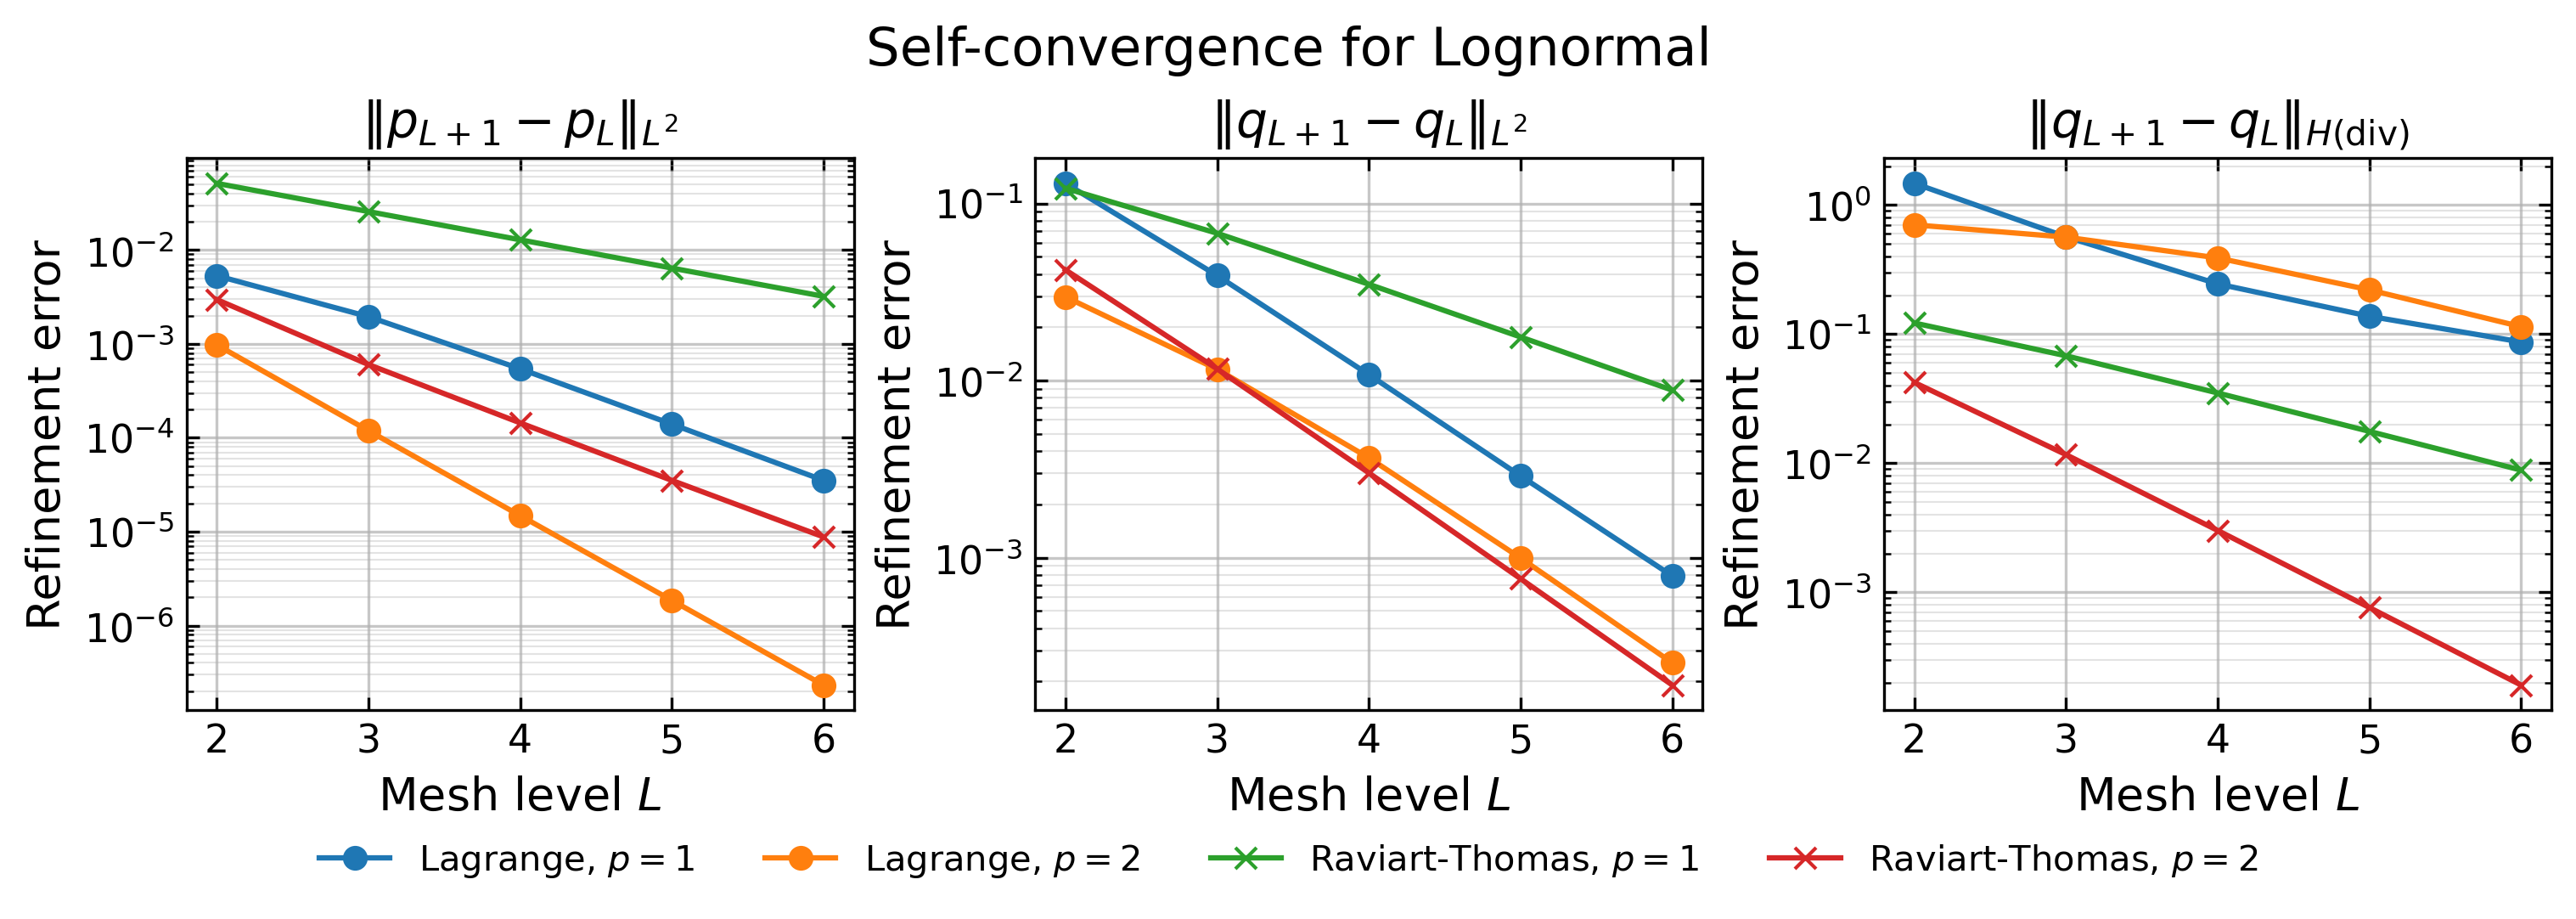

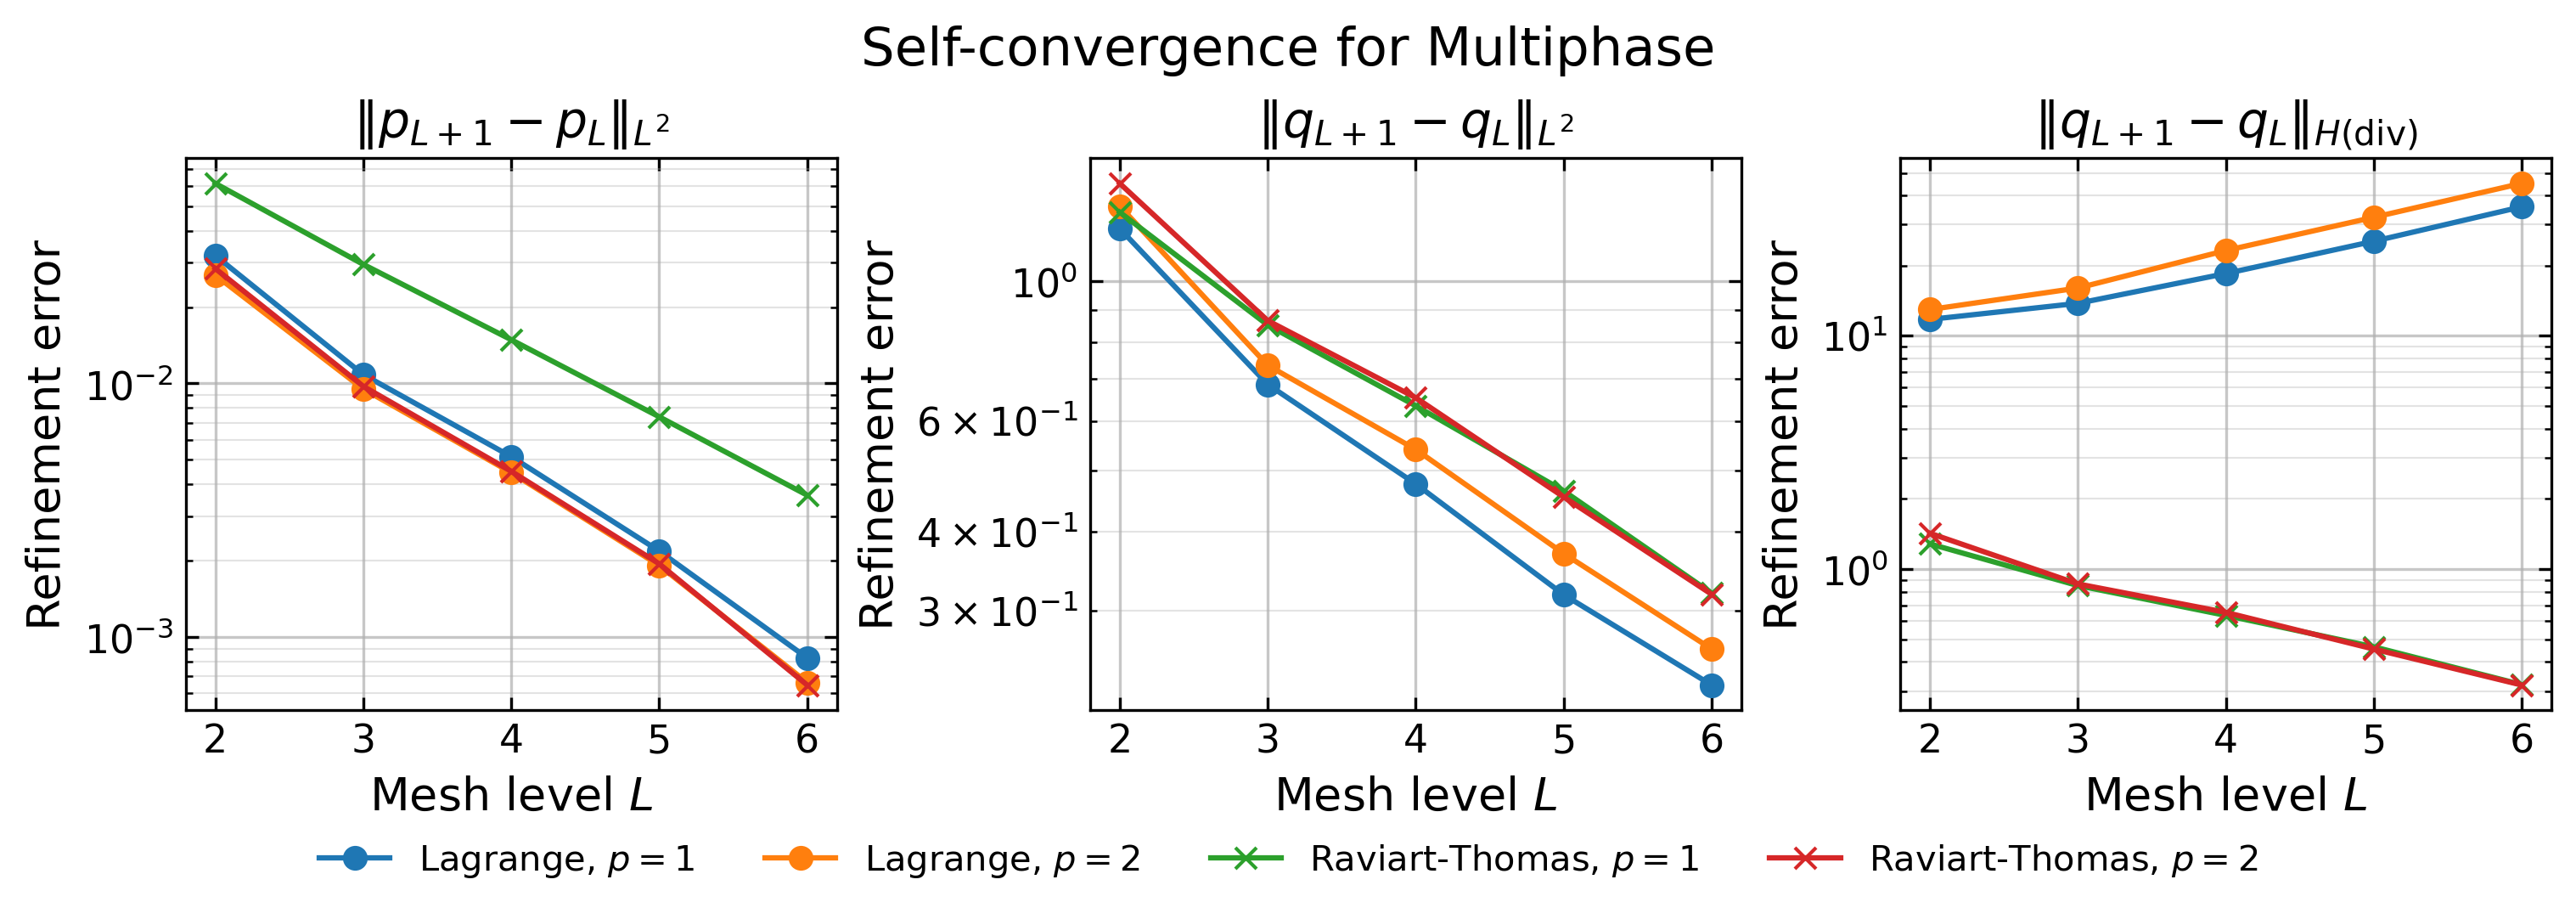

In [21]:
plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

load_path = os.path.join("pklFiles", "darcy_refinement_errors_avg.pkl")

df_refine = pd.read_pickle(load_path)

error_cols = [
    "p_L2_error",
    "q_L2_error",
    "q_Hdiv_error"
]

order_cols = {
    "p_L2_error": "p_L2_order",
    "q_L2_error": "q_L2_order",
    "q_Hdiv_error": "q_Hdiv_order"
}

error_labels = {
    "p_L2_error": r"$\|p_{L+1}-p_L\|_{L^2}$",
    "q_L2_error": r"$\|q_{L+1}-q_L\|_{L^2}$",
    "q_Hdiv_error": r"$\|q_{L+1}-q_L\|_{H(\text{div})}$"
}

field_titles = {
    "lognormal": "Lognormal",
    "multiphase": "Multiphase"
}

marker_map = {
    "CG": "o",
    "RT": "x"
}

label_map = {
    "CG": "Lagrange",
    "RT": "Raviart-Thomas"
}


for field_type in ["lognormal", "multiphase"]:

    df_plot = df_refine[df_refine["field_type"] == field_type].copy()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=300, constrained_layout=True)

    for ax, error_col in zip(axes, error_cols):

        for (element_type, degree), g in df_plot.groupby(["element_type", "degree"]):
            g = g.sort_values("mesh_level")

            order_col = order_cols[error_col]
            order_values = g[order_col].dropna()

            if len(order_values) > 0:
                order_val = order_values.iloc[-1] # Last order 
                label = (
                    rf"{label_map[element_type]}, "
                    rf"$p={degree}$"
                )
            else:
                label = rf"{label_map[element_type]}, $p={degree}$"

            ax.semilogy(g["mesh_level"], g[error_col], marker=marker_map[element_type], linewidth=1.5, label=label)

        ax.set_title(error_labels[error_col])
        ax.set_xlabel(r"Mesh level $L$")
        ax.set_ylabel("Refinement error")

        ax.grid(True, which="major", linewidth=0.8, alpha=0.7)
        ax.grid(True, which="minor", linewidth=0.5, alpha=0.35)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.tick_params(which="both", direction="in", top=True, right=True)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.1),
    )

    fig.suptitle(rf"Self-convergence for {field_titles[field_type]}", x=0.5)


    plt.show()

In [22]:
rows = []
plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

for (field_type, element_type, degree), g in df_refine.groupby(
    ["field_type", "element_type", "degree"]
):

    g = g.sort_values("mesh_level")

    p_order = g["p_L2_order"].dropna().iloc[-1]
    q_order = g["q_L2_order"].dropna().iloc[-1]
    qhdiv_order = g["q_Hdiv_order"].dropna().iloc[-1]

    mesh_level = int(g["mesh_level"].iloc[-1])
    dofs = int(g["dofs"].iloc[-1])

    rows.append(
        {
            "Field": field_type.capitalize(),
            "Method": (
                "Lagrange"
                if element_type == "CG"
                else "Raviart--Thomas"
            ),
            "Degree": degree,
            "Mesh level": mesh_level,
            "DOFs": dofs,
            "p_L2_order": round(p_order, 2),
            "q_L2_order": round(q_order, 2),
            "q_Hdiv_order": round(qhdiv_order, 2),
        }
    )

order_summary = pd.DataFrame(rows)

# Nice ordering
field_order = ["Lognormal", "Multiphase"]
method_order = ["Lagrange", "Raviart--Thomas"]

order_summary["Field"] = pd.Categorical(
    order_summary["Field"],
    categories=field_order,
    ordered=True,
)

order_summary["Method"] = pd.Categorical(
    order_summary["Method"],
    categories=method_order,
    ordered=True,
)

order_summary = (
    order_summary
    .sort_values(
        by=[
            "Field",
            "Method",
            "Degree",
        ]
    )
    .reset_index(drop=True)
)

order_summary

,Field,Method,Degree,Mesh level,DOFs,p_L2_order,q_L2_order,q_Hdiv_order
0,Lognormal,Lagrange,1,6,4225,1.99,1.87,0.66
1,Lognormal,Lagrange,2,6,16641,3.00,1.96,0.95
2,Lognormal,Raviart--Thomas,1,6,20608,1.00,1.00,1.00
3,Lognormal,Raviart--Thomas,2,6,65792,2.00,1.99,1.99
4,Multiphase,Lagrange,1,6,4225,1.40,0.48,-0.49
5,Multiphase,Lagrange,2,6,16641,1.53,0.50,-0.48
6,Multiphase,Raviart--Thomas,1,6,20608,1.03,0.54,0.54
7,Multiphase,Raviart--Thomas,2,6,65792,1.59,0.51,0.51


##### Self convergence only for multiphase

In [8]:
# Field
dim = 15
corrLength = 0.001
mu = 1.0
sigma = 0.25

phase_configs = [
    {
        "numberOfPhases": 2,
        "phaseValues": [2, 3],
        "label": "2 phases",
    },
    {
        "numberOfPhases": 3,
        "phaseValues": [2, 3, 4],
        "label": "3 phases",
    },
    {
        "numberOfPhases": 4,
        "phaseValues": [2, 3, 4, 5],
        "label": "4 phases",
    },
]

seeds = list(range(1, 11))

# FEM
elementTypes = ["CG", "RT"]
degrees = [1, 2]
mesh_levels = [2, 3, 4, 5, 6]

rows = []



def make_multiphase_field(numberOfPhases, phaseValues, seed):
    return analyticMultiphase(
        dim=dim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
        numberOfPhases=numberOfPhases,
        phaseValues=phaseValues,
        seed=seed,
    )


# Loop
configs = list(product(phase_configs, seeds, elementTypes, degrees, mesh_levels))

for phase_cfg, seed, element_type, degree, L in tqdm(
    configs,
    total=len(configs),
    desc="Multiphase refinement errors",
):

    field = make_multiphase_field(
        numberOfPhases=phase_cfg["numberOfPhases"],
        phaseValues=phase_cfg["phaseValues"],
        seed=seed,
    )

    coarse, p_c, q_c, info_c = solve_darcy(
        field=field,
        mesh_level=L,
        degree=degree,
        element_type=element_type,
    )

    fine, p_f, q_f, info_f = solve_darcy(
        field=field,
        mesh_level=L + 1,
        degree=degree,
        element_type=element_type,
    )

    # Transfer coarse solution to fine spaces
    p_c_on_fine = interpolate(p_c, fine.Vp)

    if element_type == "CG":
        q_c_on_fine = project(q_c, fine.Vq)
    else:
        q_c_on_fine = interpolate(q_c, fine.Vq)

    # Refinement differences
    p_L2_error = errornorm(
        p_f,
        p_c_on_fine,
        norm_type="L2",
        degree_rise=3,
    )

    q_L2_error = errornorm(
        q_f,
        q_c_on_fine,
        norm_type="L2",
        degree_rise=3,
    )

    q_Hdiv_error = errornorm(
        q_f,
        q_c_on_fine,
        norm_type="Hdiv",
        degree_rise=3,
    )

    rows.append(
        {
            "field_type": "multiphase",
            "n_phases": phase_cfg["numberOfPhases"],
            "phase_values": str(phase_cfg["phaseValues"]),
            "phase_label": phase_cfg["label"],
            "seed": seed,
            "element_type": element_type,
            "degree": degree,
            "mesh_level": L,
            "h": coarse.mesh.hmax(),
            "dofs": info_c["dofs"],
            "p_L2_error": p_L2_error,
            "q_L2_error": q_L2_error,
            "q_Hdiv_error": q_Hdiv_error,
            "mass_error_coarse": info_c["mass_error"],
            "mass_error_fine": info_f["mass_error"]
        }
    )


df_phase_raw = pd.DataFrame(rows)

os.makedirs("pklFiles", exist_ok=True)

save_path = os.path.join("pklFiles", "darcy_multiphase_phase_refinement_raw.pkl")

df_phase_raw.to_pickle(save_path)


df_phase_raw

Multiphase refinement errors:   1%|          | 4/600 [00:04<12:13,  1.23s/it]


KeyboardInterrupt: 

In [23]:
load_path = os.path.join("pklFiles", "darcy_multiphase_phase_refinement_raw.pkl")

df_phase_raw = pd.read_pickle(load_path)


error_cols = [
    "p_L2_error",
    "q_L2_error",
    "q_Hdiv_error",
    "mass_error"
]

# Average
df_phase = (
    df_phase_raw
    .groupby(
        [
            "n_phases",
            "phase_values",
            "phase_label",
            "element_type",
            "degree",
            "mesh_level",
        ],
        as_index=False,
    )
    .agg(
        h=("h", "mean"),
        dofs=("dofs", "mean"),
        n_fields=("seed", "nunique"),
        p_L2_error=("p_L2_error", "mean"),
        q_L2_error=("q_L2_error", "mean"),
        q_Hdiv_error=("q_Hdiv_error", "mean"),
        mass_error=("mass_error_coarse", "mean"),
        p_L2_std=("p_L2_error", "std"),
        q_L2_std=("q_L2_error", "std"),
        q_Hdiv_std=("q_Hdiv_error", "std"),
        mass_error_std=("mass_error_coarse", "std"),
    )
)

# Add orders
for err_col in error_cols:
    order_col = err_col.replace("_error", "_order")
    df_phase[order_col] = np.nan

for (n_phases, element_type, degree), g in df_phase.groupby(["n_phases", "element_type", "degree"]):
    g = g.sort_values("mesh_level")
    idx = g.index

    h = g["h"].to_numpy()

    for err_col in error_cols:
        err = g[err_col].to_numpy()
        orders = np.full(len(err), np.nan)

        for i in range(1, len(err)):
            orders[i] = (
                np.log(err[i - 1] / err[i])
                /
                np.log(h[i - 1] / h[i])
            )

        order_col = err_col.replace("_error", "_order")
        df_phase.loc[idx, order_col] = orders


df_phase = df_phase.sort_values(
    by=[
        "element_type",
        "n_phases",
        "degree",
        "mesh_level",
    ]
).reset_index(drop=True)

save_path = os.path.join("pklFiles", "darcy_multiphase_phase_refinement_avg.pkl")

df_phase.to_pickle(save_path)


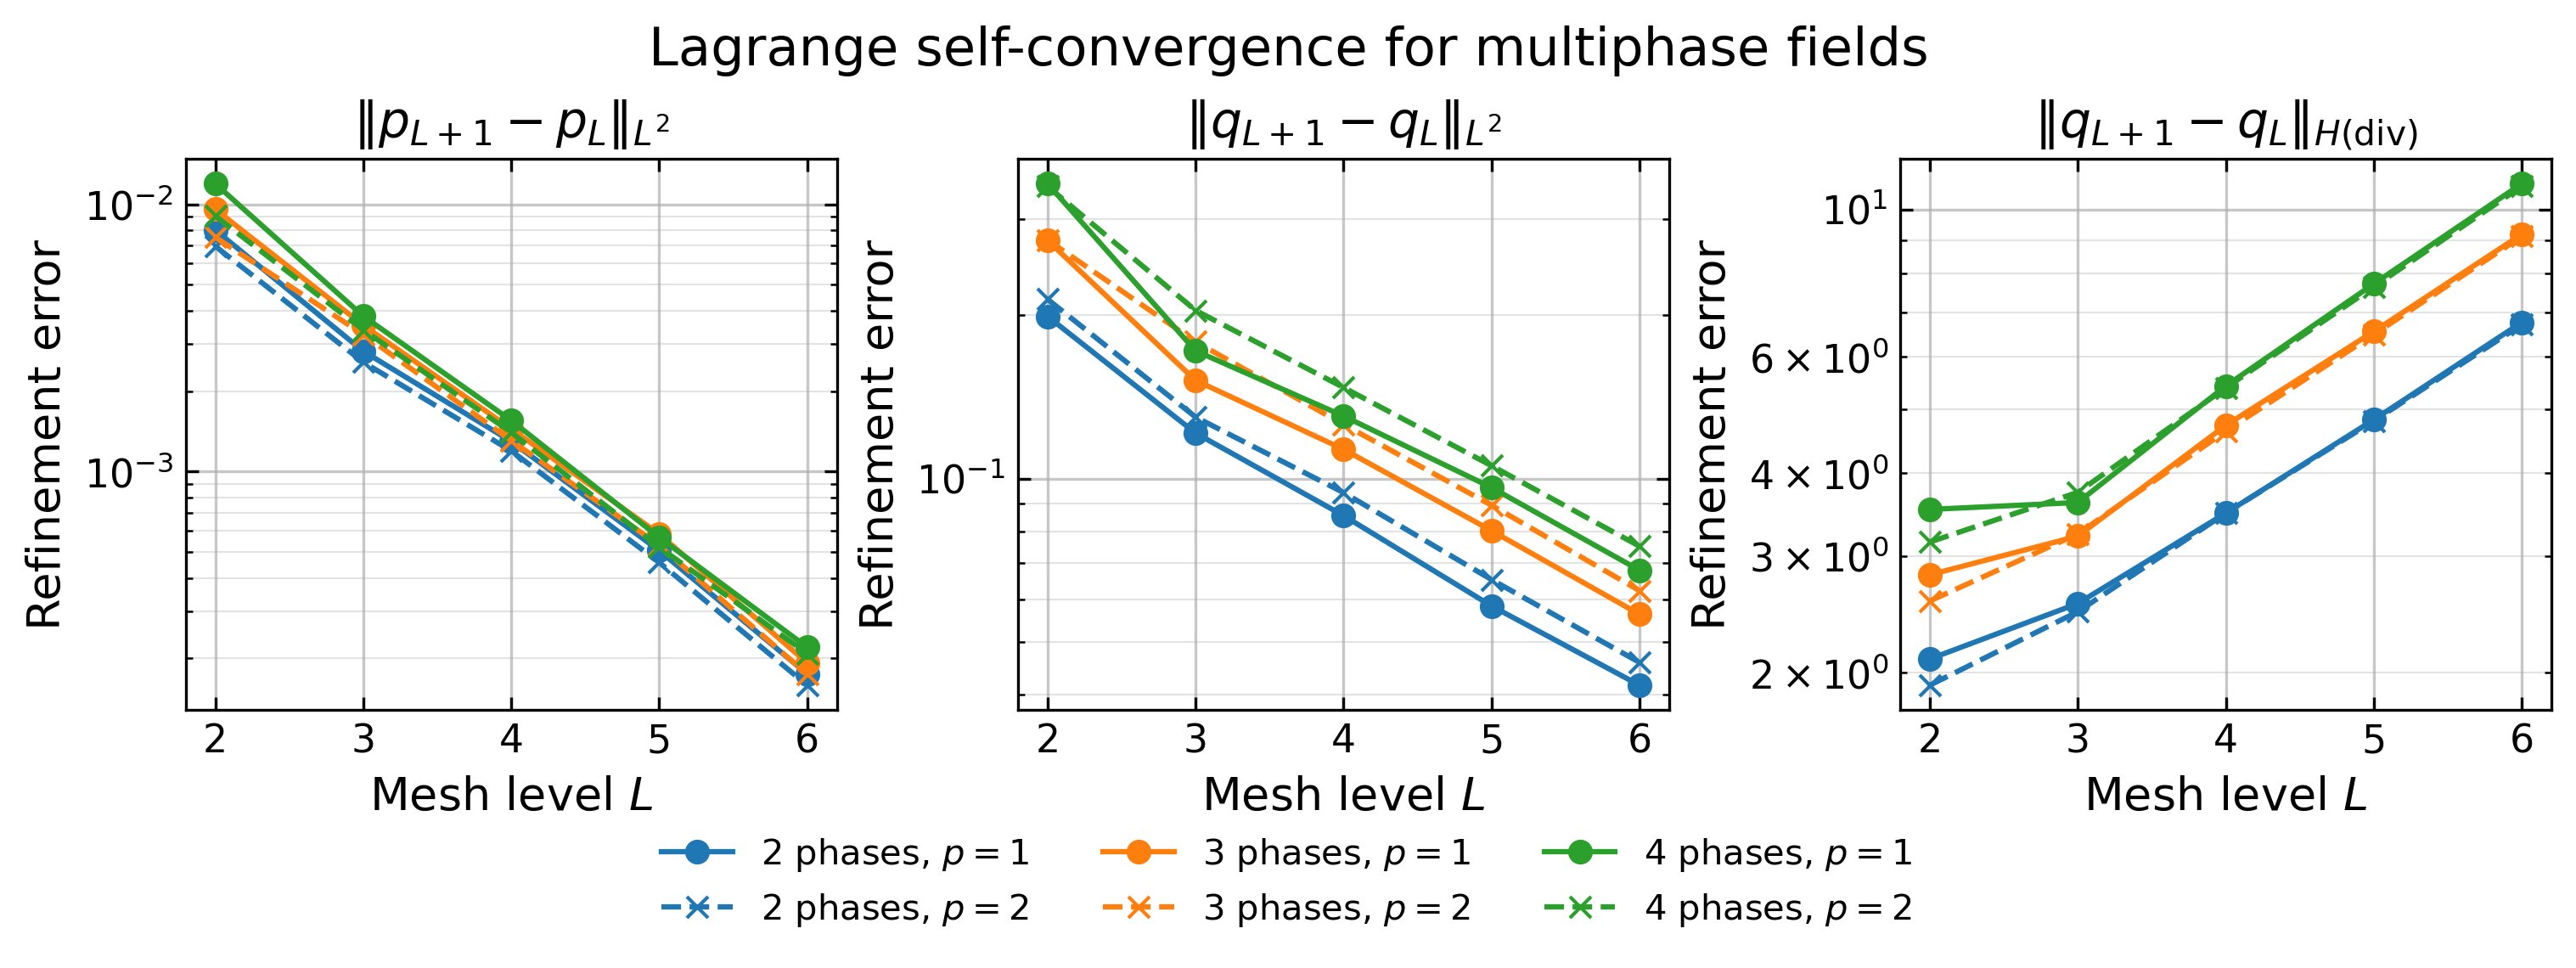

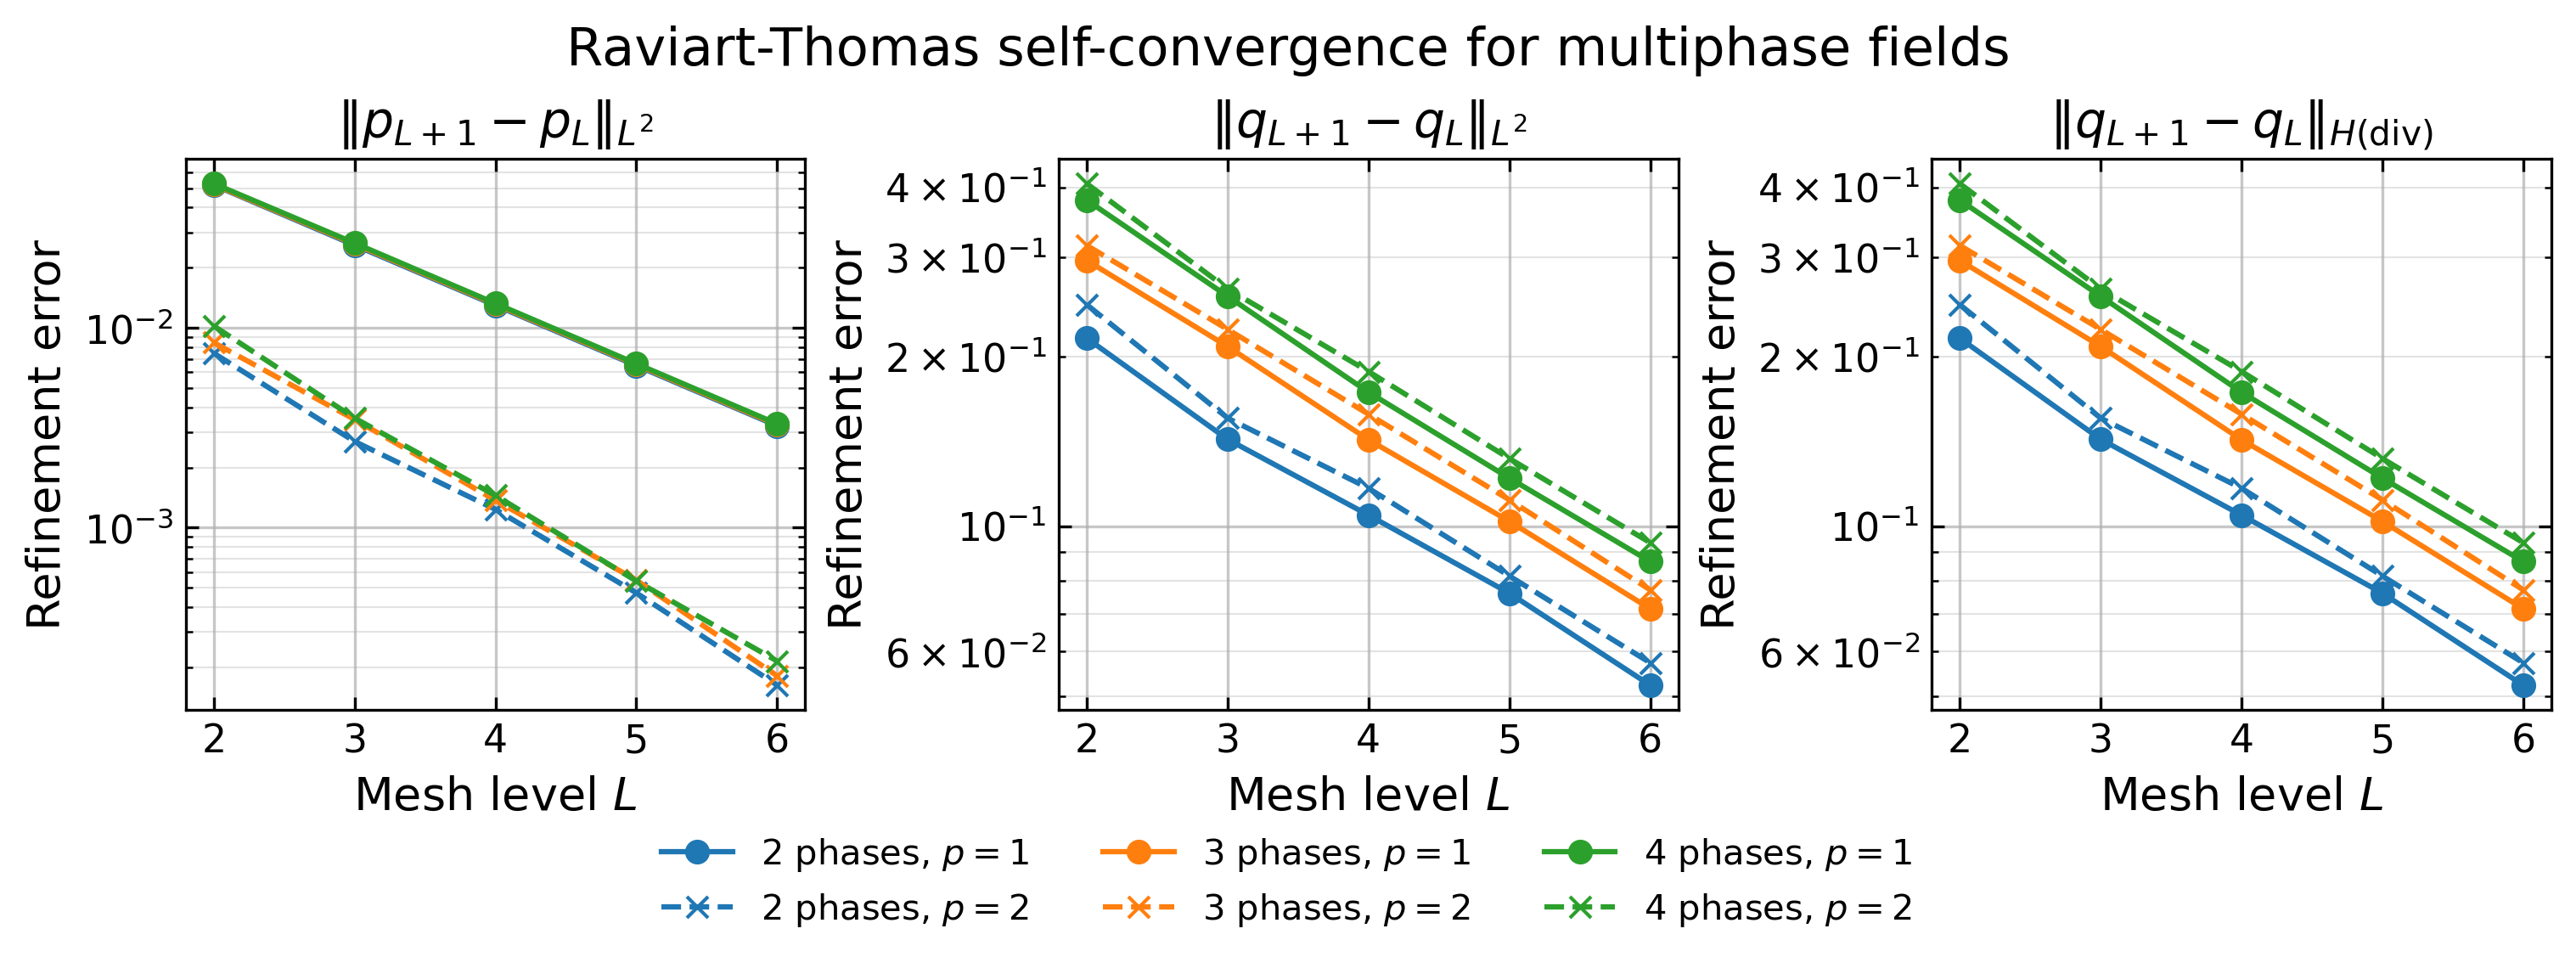

In [24]:
load_path = os.path.join("pklFiles", "darcy_multiphase_phase_refinement_avg.pkl")

plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

df_phase = pd.read_pickle(load_path)

error_cols = [
    "p_L2_error",
    "q_L2_error",
    "q_Hdiv_error",
]

order_cols = {
    "p_L2_error": "p_L2_order",
    "q_L2_error": "q_L2_order",
    "q_Hdiv_error": "q_Hdiv_order",
}

error_labels = {
    "p_L2_error": r"$\|p_{L+1}-p_L\|_{L^2}$",
    "q_L2_error": r"$\|q_{L+1}-q_L\|_{L^2}$",
    "q_Hdiv_error": r"$\|q_{L+1}-q_L\|_{H(\text{div})}$",
}

method_titles = {
    "CG": "Lagrange",
    "RT": "Raviart-Thomas",
}

marker_map = {
    1: "o",
    2: "x",
}

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

color_map = {
    2: color_cycle[0],
    3: color_cycle[1],
    4: color_cycle[2],
}

linestyle_map = {
    1: "-",
    2: "--",
}

for element_type in ["CG", "RT"]:

    df_plot = df_phase[
        df_phase["element_type"] == element_type
    ].copy()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(10, 3.2),
        dpi=300,
        constrained_layout=True,
    )

    for ax, error_col in zip(axes, error_cols):

        for (n_phases, degree), g in df_plot.groupby(
            ["n_phases", "degree"]
        ):
            g = g.sort_values("mesh_level")

            order_col = order_cols[error_col]
            order_values = g[order_col].dropna()

            if len(order_values) > 0:
                order_val = order_values.iloc[-1]
                label = (
                    rf"{n_phases} phases, "
                    rf"$p={degree}$ "
                )
            else:
                label = rf"{n_phases} phases, $p={degree}$"

            ax.semilogy(
                g["mesh_level"],
                g[error_col],
                marker=marker_map[degree],
                linestyle=linestyle_map[degree],
                color=color_map[n_phases],
                linewidth=1.5,
                label=label,
            )
        ax.set_title(error_labels[error_col])
        ax.set_xlabel(r"Mesh level $L$")
        ax.set_ylabel("Refinement error")

        ax.grid(True, which="major", linewidth=0.8, alpha=0.7)
        ax.grid(True, which="minor", linewidth=0.5, alpha=0.35)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.tick_params(which="both", direction="in", top=True, right=True)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.16)
    )

    fig.suptitle(rf"{method_titles[element_type]} self-convergence for multiphase fields", x=0.5)




    plt.show()

In [38]:
rows = []

for (
    element_type,
    n_phases,
    degree,
), g in df_phase.groupby(
    [
        "element_type",
        "n_phases",
        "degree",
    ]
):

    g = g.sort_values("mesh_level")

    # Finest refinement order
    p_order = g["p_L2_order"].dropna().iloc[-1]
    q_order = g["q_L2_order"].dropna().iloc[-1]
    qhdiv_order = g["q_Hdiv_order"].dropna().iloc[-1]

    rows.append(
        {
            "Method": (
                "Lagrange"
                if element_type == "CG"
                else "Raviart--Thomas"
            ),
            "Phases": n_phases,
            "Degree": degree,
            "p_L2_order": round(p_order, 2),
            "q_L2_order": round(q_order, 2),
            "q_Hdiv_order": round(qhdiv_order, 2),
        }
    )

order_summary = pd.DataFrame(rows)

method_order = [
    "Lagrange",
    "Raviart--Thomas",
]

order_summary["Method"] = pd.Categorical(
    order_summary["Method"],
    categories=method_order,
    ordered=True,
)

order_summary = (
    order_summary
    .sort_values(
        by=[
            "Method",
            "Phases",
            "Degree",
        ]
    )
    .reset_index(drop=True)
)

order_summary

,Method,Phases,Degree,p_L2_order,q_L2_order,q_Hdiv_order
0,Lagrange,2,1,1.53,0.48,-0.49
1,Lagrange,2,2,1.53,0.51,-0.48
2,Lagrange,3,1,1.60,0.51,-0.49
3,Lagrange,3,2,1.60,0.52,-0.49
4,Lagrange,4,1,1.37,0.51,-0.50
5,Lagrange,4,2,1.32,0.49,-0.50
6,Raviart--Thomas,2,1,1.00,0.54,0.54
7,Raviart--Thomas,2,2,1.54,0.51,0.51
8,Raviart--Thomas,3,1,1.00,0.52,0.52
9,Raviart--Thomas,3,2,1.59,0.53,0.53
